In [22]:
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


In [23]:
data = pd.read_csv('data/kc_house_data.csv')

# Remove any rows with NaN values
data = data.dropna()

#Remove columns that are not needed
data = data.drop(['id', 'date'], axis=1)
# Remove the target variable, axis=1 indicates column
training_data = data.drop('price', axis=1)
Y = data['price'].to_numpy()
y = torch.tensor(Y, dtype=torch.float32)

# Convert the DataFrame to a NumPy array
training_data = data.to_numpy()

training_data = torch.tensor(training_data, dtype=torch.float32)

X_train, X_val, y_train, y_val = train_test_split(training_data, y, test_size=0.2)


In [24]:
model = nn.Sequential(
    nn.Linear(training_data.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 254),
    nn.Linear(254, 1)
)

In [25]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss = nn.MSELoss()

train_losses = []
val_losses = []


epochs = 100
for epoch in range(epochs):
    model.train()
    # Forward pass
    outputs = model(X_train)

    
    #Calculate the loss
    MSE = loss(outputs, y_train)

    # Backward pass and optimization
    model.zero_grad()
    MSE.backward()
    optimizer.step()

      # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss(val_outputs, y_val)

    # Store losses
    train_losses.append(MSE.item())
    val_losses.append(val_loss.item())


    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {MSE.item():.4f}')

/Users/andreas/Desktop/ml-experiments/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([17288])) that is different to the input size (torch.Size([17288, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/andreas/Desktop/ml-experiments/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([4323])) that is different to the input size (torch.Size([4323, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 180389527552.0000
Epoch [20/100], Loss: 140099043328.0000
Epoch [30/100], Loss: 136364023808.0000
Epoch [40/100], Loss: 134623936512.0000
Epoch [50/100], Loss: 133344206848.0000
Epoch [60/100], Loss: 132858814464.0000
Epoch [70/100], Loss: 132696653824.0000
Epoch [80/100], Loss: 132659085312.0000
Epoch [90/100], Loss: 132507992064.0000
Epoch [100/100], Loss: 132474306560.0000


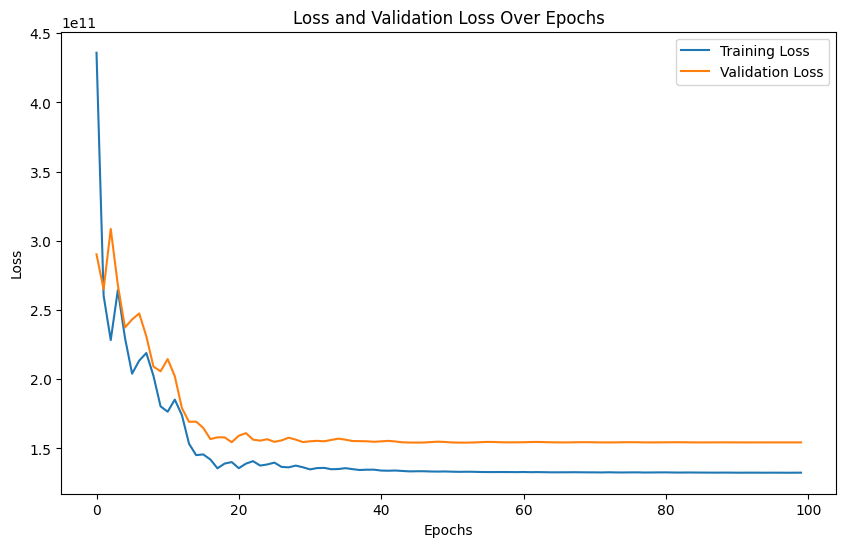

In [26]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()